<a href="https://colab.research.google.com/github/samitastic/CSL701-52_Machine-Learning-Lab/blob/main/Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Samita Ganesh Sharma
Roll No : CS52

Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.


Task 1 : Import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving auto-mpg (3).csv to auto-mpg (3) (1).csv


Task 2 : Load Auto MPG Dataset

In [4]:
df = pd.read_csv("auto-mpg (3).csv")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Task 3:Inspect and clean data


In [26]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

#Cleaning of data
# Convert horsepower to numeric
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# Remove rows where horsepower or mpg is missing
df = df.dropna(subset=["horsepower", "mpg"])

print("Shape after cleaning:", df.shape)

print("\nMissing values after cleaning:")
print(df[["horsepower", "mpg"]].isnull().sum())

Shape of dataset: (392, 9)

Column names:
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

First 5 rows:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model year  origin                   car name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 

Task 4: Selecting horsepower and MPG

In [27]:
X = df["horsepower"].values
y = df["mpg"].values

print("Horsepower values:")
print(X[:10])

print("\nMPG values:")
print(y[:10])

Horsepower values:
[130. 165. 150. 150. 140. 198. 220. 215. 225. 190.]

MPG values:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]


Task 5: Plot the scatter graph

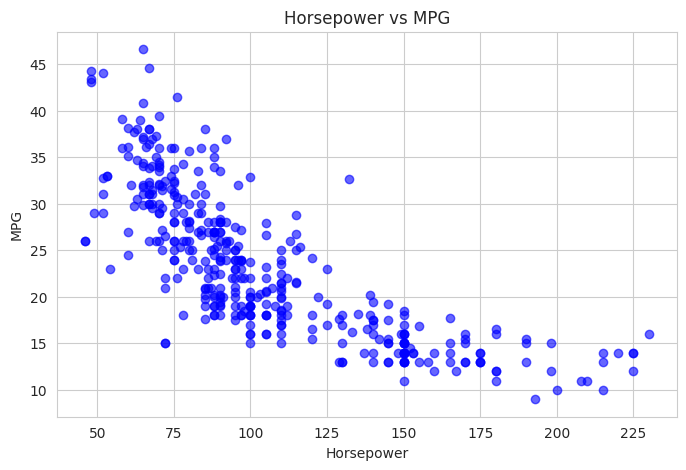

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, color="blue", alpha=0.6)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")

plt.grid(True)

Task 6: Add the bias/intercept term

In [29]:
X_bias = np.column_stack((np.ones(len(X)), X))
print(X_bias[:5])

[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


Task 7: Calculate correlation

In [30]:
correlation = np.corrcoef(X, y)[0, 1]
print("Correlation between Horsepower and MPG:", correlation)


Correlation between Horsepower and MPG: -0.7784267838977756


Task 8:Calculate OLS weights

In [31]:
# OLS calculation
weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

w0 = weights[0]
w1 = weights[1]

print("Intercept (w0):", w0)
print("Slope (w1):", w1)

Intercept (w0): 39.9358610211705
Slope (w1): -0.15784473335365387


Task 9: Predict MPG values

In [32]:
y_pred = X_bias @ weights

print("Actual MPG:")
print(y[:10])

print("\nPredicted MPG:")
print(y_pred[:10])

Actual MPG:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]

Predicted MPG:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


Task 10: Calculate residuals

In [33]:
residuals = y - y_pred

print("First 10 residuals:")
print(residuals[:10])


First 10 residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


Task 11: Calculate SSE, MSE, R²

In [34]:
#Calculate SSE
SSE = np.sum(residuals ** 2)
print("SSE:", SSE)

#Calculate MSE
MSE = np.mean(residuals ** 2)
print("MSE:", MSE)

#Calculate R²
SS_total = np.sum((y - np.mean(y)) ** 2)
R2 = 1 - (SSE / SS_total)
print("R²:", R2)

SSE: 9385.915871932419
MSE: 23.943662938603108
R²: 0.6059482578894348


In [37]:
print("========== OLS RESULTS ==========")
print("Intercept (w0):", w0)
print("Slope (w1):", w1)
print("Correlation:", correlation)
print("SSE:", SSE)
print("MSE:", MSE)
print("R²:", R2)

========== OLS RESULTS ==========
Intercept (w0): 39.9358610211705
Slope (w1): -0.15784473335365387
Correlation: -0.7784267838977756
SSE: 9385.915871932419
MSE: 23.943662938603108
R²: 0.6059482578894348


Task 12: Plot regression and residual graphs


========== OLS RESULTS ==========
Intercept (w0): 39.9358610211705
Slope (w1): -0.15784473335365387
Correlation: -0.7784267838977756
SSE: 9385.915871932419
MSE: 23.943662938603108
R²: 0.6059482578894348


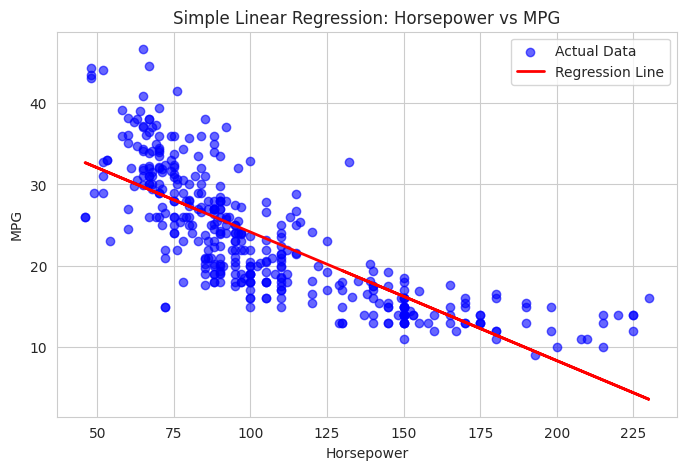

In [35]:

#Plot regression line
plt.figure(figsize=(8, 5))

plt.scatter(X, y, color="blue", alpha=0.6, label="Actual Data")

plt.plot(X, y_pred, color="red", linewidth=2, label="Regression Line")

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression: Horsepower vs MPG")

plt.legend()
plt.grid(True)
plt.show()

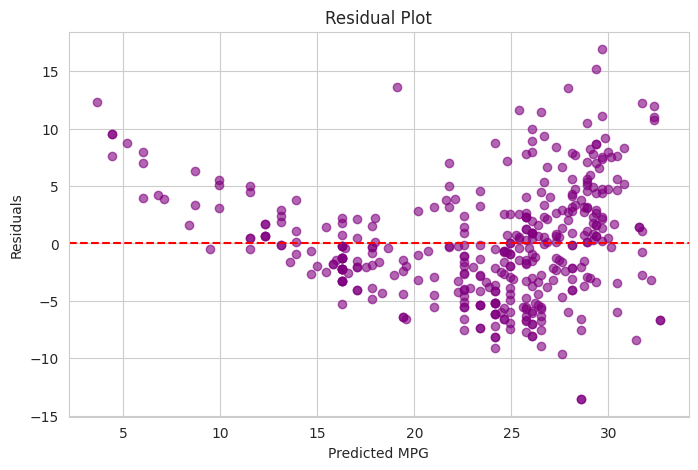

In [36]:
#Plot residual graph
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, color="purple", alpha=0.6)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)
plt.show()